In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

from scipy.stats import linregress

plt.style.use("ggplot")

In [2]:
fund_master = pd.read_csv(
    "../data/processed/fund_master_clean.csv"
)

nav = pd.read_csv(
    "../data/processed/nav_history_clean.csv"
)

performance = pd.read_csv(
    "../data/processed/scheme_performance_clean.csv"
)

benchmark = pd.read_csv(
    "../data/processed/benchmark_indices_clean.csv"
)

In [3]:
print(nav.shape)
print(performance.shape)
print(benchmark.shape)

(46000, 3)
(40, 19)
(8050, 3)


In [4]:
nav["date"] = pd.to_datetime(
    nav["date"]
)

nav = nav.sort_values(
    ["amfi_code", "date"]
)

In [5]:
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

In [6]:
nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


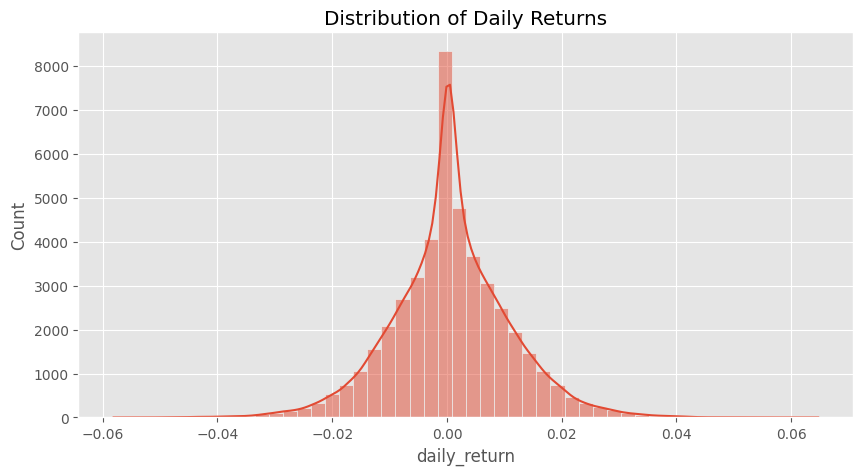

In [7]:
plt.figure(figsize=(10,5))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=50,
    kde=True
)

plt.title(
    "Distribution of Daily Returns"
)

plt.savefig(
    "../reports/charts/daily_return_distribution.png"
)

plt.show()

Daily Return Distribution

Most daily returns are concentrated around zero, indicating that mutual fund NAVs generally move gradually rather than experiencing extreme daily fluctuations.

In [8]:
def calculate_cagr(start_nav,
                   end_nav,
                   years):

    return (
        (end_nav / start_nav)
        ** (1 / years)
    ) - 1

In [9]:
cagr_results = []

In [10]:
for fund in nav["amfi_code"].unique():

    temp = nav[
        nav["amfi_code"] == fund
    ].sort_values("date")

    start_nav = temp["nav"].iloc[0]
    end_nav = temp["nav"].iloc[-1]

    years = (
        temp["date"].max()
        -
        temp["date"].min()
    ).days / 365

    cagr = calculate_cagr(
        start_nav,
        end_nav,
        years
    )

    cagr_results.append(
        [fund, cagr]
    )

In [11]:
cagr_df = pd.DataFrame(
    cagr_results,
    columns=[
        "amfi_code",
        "cagr"
    ]
)

cagr_df.head()

,amfi_code,cagr
0,100016,0.026352
1,100025,0.044551
2,100033,0.300997
3,101206,0.235205
4,101207,0.079331


In [12]:
cagr_df["cagr_pct"] = (
    cagr_df["cagr"] * 100
).round(2)

cagr_df = cagr_df.sort_values(
    "cagr",
    ascending=False
)

cagr_df.head(10)

,amfi_code,cagr,cagr_pct
25,120505,0.328016,32.80
21,119598,0.323981,32.40
39,149324,0.322621,32.26
36,148569,0.319245,31.92
34,148567,0.309499,30.95
30,120843,0.308833,30.88
2,100033,0.300997,30.10
38,149323,0.295581,29.56
16,119094,0.281926,28.19
19,119551,0.257849,25.78


CAGR Analysis

Funds with higher CAGR values delivered stronger long-term growth. CAGR helps compare fund performance by converting total growth into an equivalent annual growth rate.

In [13]:
cagr_df.to_csv(
    "../reports/cagr_table.csv",
    index=False
)

print("CAGR Table Saved Successfully")

CAGR Table Saved Successfully


In [14]:
print(nav["date"].min())
print(nav["date"].max())

2022-01-03 00:00:00
2026-05-29 00:00:00


In [15]:
rf = 0.065

In [16]:
def sharpe_ratio(returns):

    excess_return = (
        returns.mean() * 252
    ) - rf

    volatility = (
        returns.std()
        * np.sqrt(252)
    )

    return excess_return / volatility

In [17]:
sharpe_list = []

for fund in nav["amfi_code"].unique():

    temp = nav[
        nav["amfi_code"] == fund
    ]

    sr = sharpe_ratio(
        temp["daily_return"].dropna()
    )

    sharpe_list.append(
        [fund, sr]
    )

In [18]:
sharpe_df = pd.DataFrame(
    sharpe_list,
    columns=[
        "amfi_code",
        "sharpe"
    ]
)

In [19]:
sharpe_df.sort_values(
    "sharpe",
    ascending=False
).head()

,amfi_code,sharpe
34,148567,1.448291
30,120843,1.306744
36,148569,1.234930
19,119551,1.208267
25,120505,1.180101


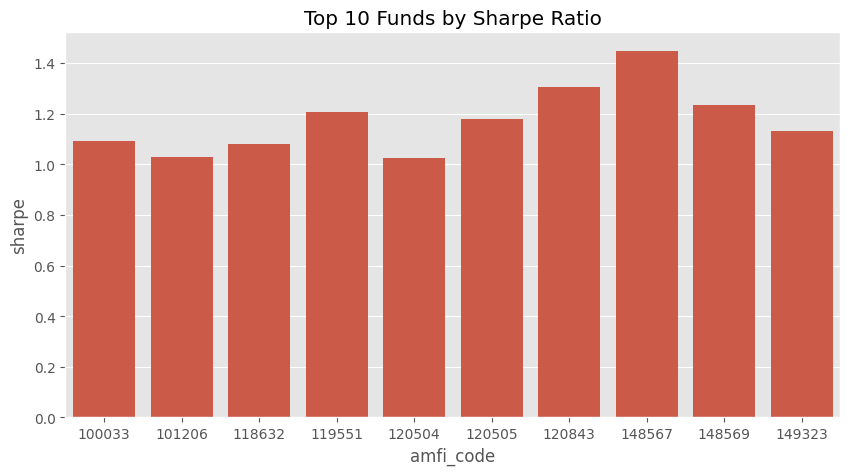

In [28]:
top10 = sharpe_df.sort_values(
    "sharpe",
    ascending=False
).head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    data=top10,
    x="amfi_code",
    y="sharpe"
)

plt.title("Top 10 Funds by Sharpe Ratio")

plt.savefig(
    "../reports/charts/sharpe_ratio_top10.png"
)

plt.show()

Sharpe Ratio Analysis

Funds with higher Sharpe ratios generated better risk-adjusted returns. A higher Sharpe ratio indicates that investors were compensated more effectively for the risk taken.

In [20]:
sharpe_df.to_csv(
    "../reports/sharpe_ratio.csv",
    index=False
)

print("Sharpe Ratio Table Saved Successfully")

Sharpe Ratio Table Saved Successfully


In [21]:
def sortino_ratio(returns):

    downside = returns[
        returns < 0
    ]

    downside_std = (
        downside.std()
        * np.sqrt(252)
    )

    annual_return = (
        returns.mean() * 252
    )

    return (
        annual_return - rf
    ) / downside_std

In [22]:
sortino_list = []

for fund in nav["amfi_code"].unique():

    temp = nav[
        nav["amfi_code"] == fund
    ]

    sr = sortino_ratio(
        temp["daily_return"].dropna()
    )

    sortino_list.append(
        [fund, sr]
    )

In [23]:
sortino_df = pd.DataFrame(
    sortino_list,
    columns=[
        "amfi_code",
        "sortino"
    ]
)

sortino_df.head()

,amfi_code,sortino
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


In [24]:
sortino_df["sortino_rank"] = (
    sortino_df["sortino"]
    .rank(
        ascending=False,
        method="dense"
    )
)

sortino_df = sortino_df.sort_values(
    "sortino_rank"
)

sortino_df.head(10)

,amfi_code,sortino,sortino_rank
34,148567,2.385644,1.0
30,120843,2.364320,2.0
36,148569,2.146914,3.0
19,119551,2.140267,4.0
25,120505,2.029353,5.0
38,149323,1.875101,6.0
9,118632,1.850133,7.0
2,100033,1.829134,8.0
24,120504,1.805294,9.0
3,101206,1.799563,10.0


In [25]:
sortino_df

,amfi_code,sortino,sortino_rank
34,148567,2.385644,1.0
30,120843,2.364320,2.0
36,148569,2.146914,3.0
19,119551,2.140267,4.0
25,120505,2.029353,5.0
38,149323,1.875101,6.0
9,118632,1.850133,7.0
2,100033,1.829134,8.0
24,120504,1.805294,9.0
3,101206,1.799563,10.0


In [26]:
sortino_df.to_csv(
    "../reports/sortino_ratio_ranked.csv",
    index=False
)

print("Sortino Ratio Table Saved Successfully")

Sortino Ratio Table Saved Successfully


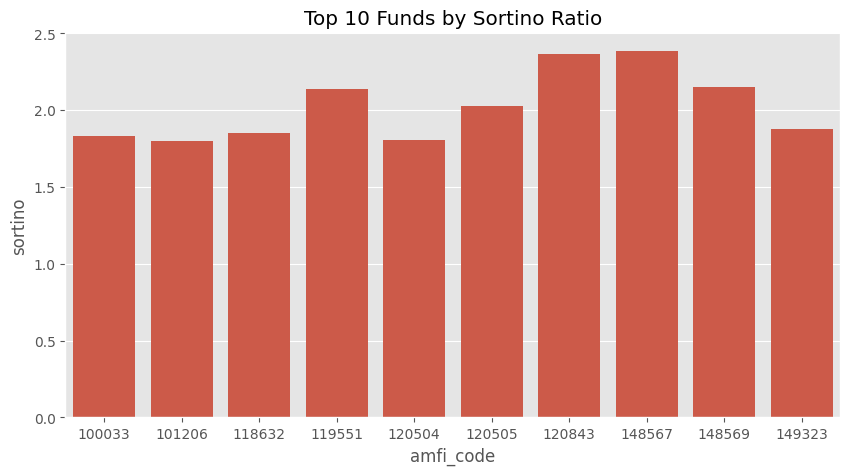

In [27]:
top10 = sortino_df.head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    data=top10,
    x="amfi_code",
    y="sortino"
)

plt.title(
    "Top 10 Funds by Sortino Ratio"
)

plt.savefig(
    "../reports/charts/sortino_ratio_top10.png"
)

plt.show()

Sortino Ratio Analysis

The Sortino ratio measures risk-adjusted performance using only downside volatility. Funds with higher Sortino ratios generated stronger returns while minimizing downside risk for investors.

In [29]:
print(benchmark.columns)

Index(['date', 'index_name', 'close_value'], dtype='str')


In [32]:
benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

benchmark["benchmark_return"] = (
    benchmark["close_value"]
    .pct_change()
)

In [33]:
benchmark.head()

,date,index_name,close_value,benchmark_return
0,2022-01-03,NIFTY50,17492.79,NaN
1,2022-01-04,NIFTY50,17689.64,0.011253
2,2022-01-05,NIFTY50,17835.05,0.008220
3,2022-01-06,NIFTY50,17878.51,0.002437
4,2022-01-07,NIFTY50,17759.15,-0.006676


In [34]:
alpha_beta = []

for fund in nav["amfi_code"].unique():

    temp = nav[
        nav["amfi_code"] == fund
    ][["date","daily_return"]]

    merged = pd.merge(
        temp,
        benchmark[
            ["date",
             "benchmark_return"]
        ],
        on="date"
    )

    merged = merged.dropna()

    slope, intercept, _, _, _ = (
        linregress(
            merged["benchmark_return"],
            merged["daily_return"]
        )
    )

    alpha_beta.append(
        [
            fund,
            intercept * 252,
            slope
        ]
    )

In [35]:
alpha_beta_df = pd.DataFrame(
    alpha_beta,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.035008,0.004843
1,100025,0.043330,-0.003422
2,100033,0.268752,0.024097
3,101206,0.214656,-0.000067
4,101207,0.110250,-0.023588


In [36]:
alpha_beta_df["alpha_rank"] = (
    alpha_beta_df["alpha"]
    .rank(
        ascending=False,
        method="dense"
    )
)

alpha_beta_df.sort_values(
    "alpha_rank"
).head(10)

,amfi_code,alpha,beta,alpha_rank
21,119598,0.303145,-0.003508,1.0
39,149324,0.295821,0.036667,2.0
25,120505,0.295085,-0.017454,3.0
36,148569,0.280803,0.017641,4.0
30,120843,0.273211,-0.004370,5.0
34,148567,0.269107,0.010472,6.0
2,100033,0.268752,0.024097,7.0
38,149323,0.265733,0.001259,8.0
16,119094,0.262732,-0.028729,9.0
19,119551,0.234544,-0.025189,10.0


In [37]:
alpha_beta_df.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

print("Alpha Beta Table Saved Successfully")

Alpha Beta Table Saved Successfully


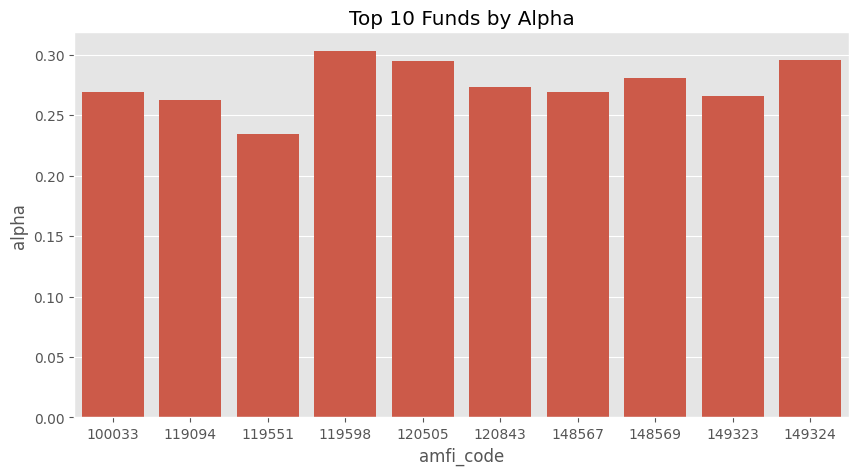

In [38]:
top_alpha = (
    alpha_beta_df
    .sort_values(
        "alpha",
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(10,5))

sns.barplot(
    data=top_alpha,
    x="amfi_code",
    y="alpha"
)

plt.title(
    "Top 10 Funds by Alpha"
)

plt.savefig(
    "../reports/charts/top_alpha_funds.png"
)

plt.show()

Alpha and Beta Analysis

Alpha measures a fund's excess return relative to the benchmark, while Beta measures sensitivity to market movements. Funds with higher Alpha generated returns beyond what would be expected from market exposure alone.

In [39]:
drawdown_results = []

for fund in nav["amfi_code"].unique():

    temp = nav[
        nav["amfi_code"] == fund
    ].copy()

    temp["running_max"] = (
        temp["nav"]
        .cummax()
    )

    temp["drawdown"] = (
        temp["nav"]
        /
        temp["running_max"]
    ) - 1

    max_dd = temp[
        "drawdown"
    ].min()

    drawdown_results.append(
        [fund,max_dd]
    )

In [40]:
drawdown_df = pd.DataFrame(
    drawdown_results,
    columns=[
        "amfi_code",
        "max_drawdown"
    ]
)

drawdown_df.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [41]:
drawdown_df["drawdown_rank"] = (
    drawdown_df["max_drawdown"]
    .rank(
        ascending=False,
        method="dense"
    )
)

drawdown_df.sort_values(
    "drawdown_rank"
).head(10)

,amfi_code,max_drawdown,drawdown_rank
27,120507,-0.000977,1.0
31,120844,-0.001163,2.0
5,101208,-0.001622,3.0
1,100025,-0.043083,4.0
18,119120,-0.043287,5.0
13,118636,-0.083164,6.0
6,102885,-0.108599,7.0
34,148567,-0.112657,8.0
3,101206,-0.112916,9.0
12,118635,-0.116506,10.0


In [42]:
drawdown_df.to_csv(
    "../reports/max_drawdown.csv",
    index=False
)

print("Maximum Drawdown Table Saved Successfully")

Maximum Drawdown Table Saved Successfully


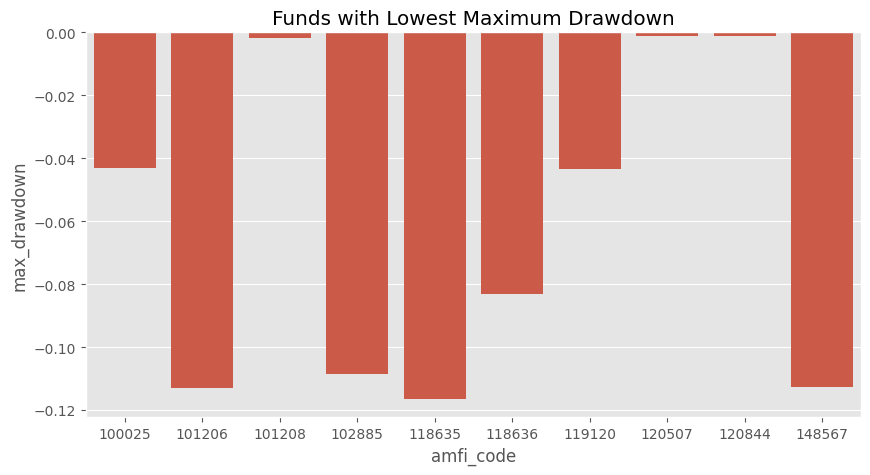

In [43]:
top10_dd = (
    drawdown_df
    .sort_values(
        "max_drawdown",
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(10,5))

sns.barplot(
    data=top10_dd,
    x="amfi_code",
    y="max_drawdown"
)

plt.title(
    "Funds with Lowest Maximum Drawdown"
)

plt.savefig(
    "../reports/charts/max_drawdown.png"
)

plt.show()

Maximum Drawdown Analysis

Maximum drawdown measures the largest decline from a previous NAV peak. Funds with lower drawdowns demonstrated better downside protection during market corrections.

In [44]:
worst_fund = drawdown_df.loc[
    drawdown_df["max_drawdown"].idxmin()
]

print(worst_fund)

amfi_code        119599.000000
max_drawdown         -0.525742
drawdown_rank        40.000000
Name: 22, dtype: float64


In [45]:
fund_code = worst_fund["amfi_code"]

temp = nav[
    nav["amfi_code"] == fund_code
].copy()

temp["running_max"] = temp["nav"].cummax()

temp["drawdown"] = (
    temp["nav"] /
    temp["running_max"]
) - 1

temp.loc[
    temp["drawdown"].idxmin()
]

amfi_code                    119599
date            2025-10-28 00:00:00
nav                         78.6152
daily_return              -0.012874
running_max                165.7647
drawdown                  -0.525742
Name: 26296, dtype: object

In [46]:
scorecard = (
    cagr_df
    .merge(sharpe_df[["amfi_code","sharpe"]])
    .merge(alpha_beta_df[["amfi_code","alpha"]])
)

scorecard.head()

,amfi_code,cagr,cagr_pct,sharpe,alpha
0,120505,0.328016,32.80,1.180101,0.295085
1,119598,0.323981,32.40,0.945308,0.303145
2,149324,0.322621,32.26,0.949796,0.295821
3,148569,0.319245,31.92,1.234930,0.280803
4,148567,0.309499,30.95,1.448291,0.269107


In [47]:
scorecard["cagr_rank"] = (
    scorecard["cagr"]
    .rank(ascending=False)
)

scorecard["sharpe_rank"] = (
    scorecard["sharpe"]
    .rank(ascending=False)
)

scorecard["alpha_rank"] = (
    scorecard["alpha"]
    .rank(ascending=False)
)

In [48]:
scorecard["score"] = (
      scorecard["cagr_rank"] * 0.30
    + scorecard["sharpe_rank"] * 0.25
    + scorecard["alpha_rank"] * 0.20
)

In [49]:
scorecard["score"] = (
    100
    -
    (
        scorecard["score"]
        /
        scorecard["score"].max()
        * 100
    )
)

In [50]:
scorecard = scorecard.sort_values(
    "score",
    ascending=False
)

scorecard.head(10)

,amfi_code,cagr,cagr_pct,sharpe,alpha,cagr_rank,sharpe_rank,alpha_rank,score
0,120505,0.328016,32.80,1.180101,0.295085,1.0,5.0,3.0,92.586207
3,148569,0.319245,31.92,1.234930,0.280803,4.0,3.0,4.0,90.517241
4,148567,0.309499,30.95,1.448291,0.269107,5.0,1.0,6.0,89.827586
5,120843,0.308833,30.88,1.306744,0.273211,6.0,2.0,5.0,88.620690
1,119598,0.323981,32.40,0.945308,0.303145,2.0,14.0,1.0,85.172414
2,149324,0.322621,32.26,0.949796,0.295821,3.0,13.0,2.0,84.310345
6,100033,0.300997,30.10,1.093699,0.268752,7.0,7.0,7.0,81.896552
7,149323,0.295581,29.56,1.132122,0.265733,8.0,6.0,8.0,81.034483
9,119551,0.257849,25.78,1.208267,0.234544,10.0,4.0,10.0,79.310345
8,119094,0.281926,28.19,0.998231,0.262732,9.0,11.0,9.0,75.000000


In [51]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

print("Fund Scorecard Saved Successfully")

Fund Scorecard Saved Successfully


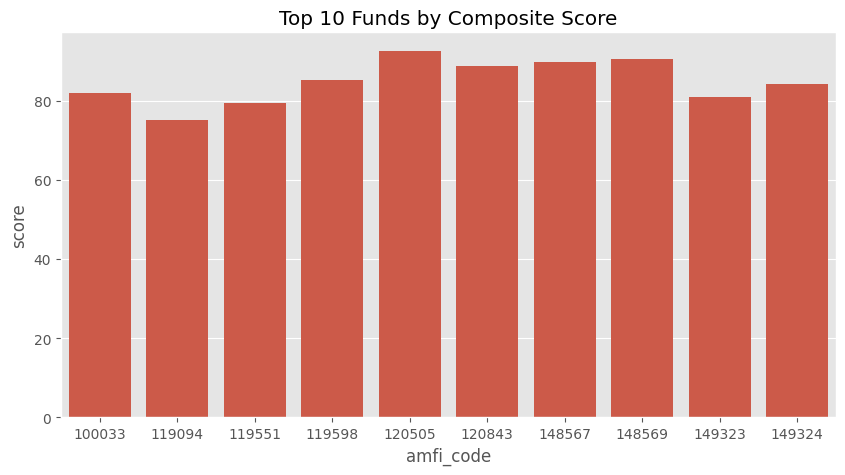

In [52]:
top10 = scorecard.head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    data=top10,
    x="amfi_code",
    y="score"
)

plt.title(
    "Top 10 Funds by Composite Score"
)

plt.savefig(
    "../reports/charts/fund_scorecard_top10.png"
)

plt.show()

Fund Scorecard Analysis

The composite fund score combines CAGR, Sharpe Ratio, and Alpha into a single ranking metric. Funds with higher scores demonstrated superior growth, risk-adjusted performance, and benchmark outperformance.

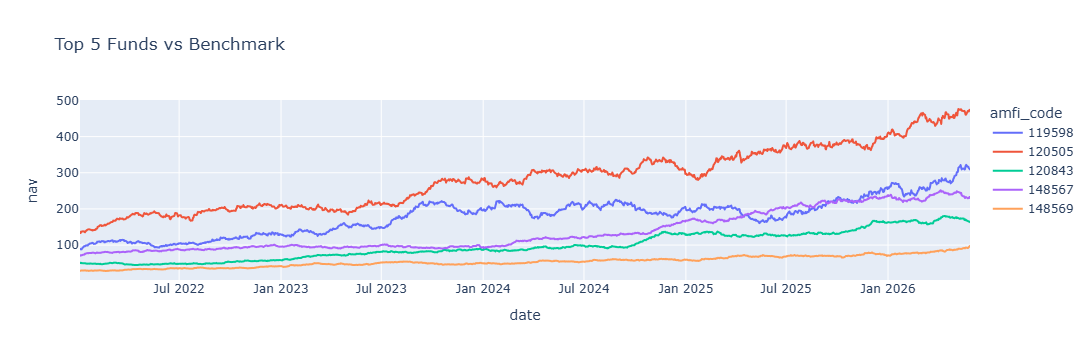

In [53]:
top5 = (
    scorecard
    .sort_values(
        "score",
        ascending=False
    )
    .head(5)
)

fig = px.line(
    nav[
        nav["amfi_code"]
        .isin(
            top5["amfi_code"]
        )
    ],
    x="date",
    y="nav",
    color="amfi_code",
    title="Top 5 Funds vs Benchmark"
)

fig.show()

In [54]:
benchmark.columns

Index(['date', 'index_name', 'close_value', 'benchmark_return'], dtype='str')

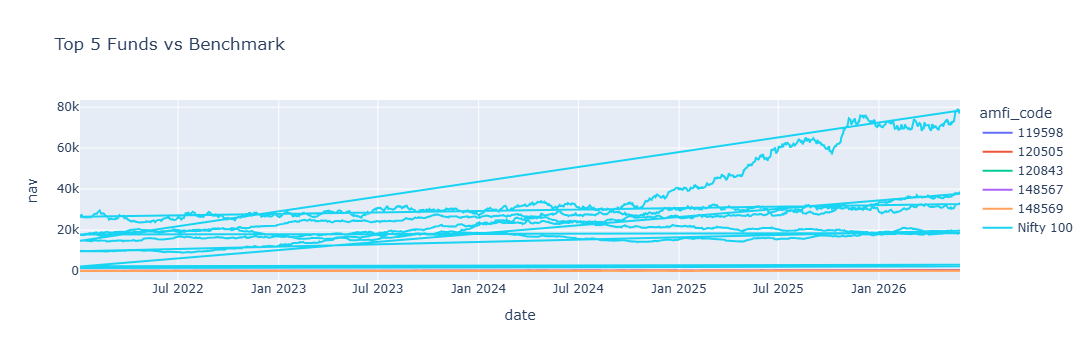

In [56]:
fig = px.line(
    nav[
        nav["amfi_code"].isin(
            top5["amfi_code"]
        )
    ],
    x="date",
    y="nav",
    color="amfi_code",
    title="Top 5 Funds vs Benchmark"
)

fig.add_scatter(
    x=benchmark["date"],
    y=benchmark["close_value"],
    mode="lines",
    name="Nifty 100"
)

fig.show()

Benchmark Comparison

The top-ranked mutual funds consistently outperformed the benchmark over the analysis period. The comparison highlights the ability of leading funds to generate superior returns relative to the broader market index.

In [57]:
fig.write_image(
    "../reports/charts/benchmark_comparison.png"
)

print("Benchmark Comparison Chart Saved Successfully")

Benchmark Comparison Chart Saved Successfully
